<a href="https://colab.research.google.com/github/mhabibier/scikit-learn-cookbook/blob/main/06_Advanced_Logistic_Regression_and_Extensions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 — Advanced Logistic Regression and Extensions

**scikit-learn Cookbook, Third Edition  John Sukup (Packt, 2025)**  
**Nama:** Muhammad Habibie Rabbani · **Kelas:** TK-47-04

## Tujuan pembelajaran
Menjelaskan probabilitas logistic regression, membedakan klasifikasi biner/multiclass/multilabel, menilai pengaruh regularisasi, dan mengevaluasi kesalahan tiap kelas secara tepat.

## Peta reproduksi
Notebook ini mengadaptasi notebook bab utama dan *Exercise Solutions* dari [kode pendamping resmi](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500), commit `c624b1279cf23a83273e806cede15cad0c9e5500`. Penjelasan ditulis ulang dalam Bahasa Indonesia; kode disesuaikan agar dapat dijalankan pada lingkungan yang dicatat di bawah. Penomoran bagian mengikuti alur konsep sumber, bukan nomor halaman PDF. Buku tetap referensi utama untuk membaca uraian lengkap.

| Resep sumber | Bagian notebook |
|---|---|
| Binary logistic regression | 1–2: Breast Cancer, baseline dan audit |
| Multiclass logistic regression | 3: Iris, OvR dan multinomial |
| Regularization | 4: L1/L2 dan jalur koefisien |
| Multilabel classification | 5: lima label, co-occurrence |
| Evaluation metrics | 6: confusion matrix, ROC, PR |
| Exercises 1–3 | 7: regularisasi, multinomial, decision boundary |

## Penyesuaian dan batas reproduksi
Split dan seed utama mengikuti resep (80/20 untuk binary; 70/30 untuk bagian lain), dengan **stratifikasi ditambahkan** pada klasifikasi single-label. Standardisasi ditempatkan di Pipeline. API scikit-learn 1.8 menggunakan `l1_ratio`; `liblinear` multiclass dibungkus `OneVsRestClassifier`. Kelas positif klinis dinyatakan eksplisit: malignant = 0. Judul latihan sumber “Ridge Regression” sebenarnya memberi instruksi regularisasi logistic L1/L2; latihan di sini melaksanakan keduanya. Ini demo benchmark, bukan model diagnosis klinis.

## Cara menjalankan
Jalankan **Restart Kernel → Run All** dari atas ke bawah. Setiap notebook mandiri. Gunakan Python 3.12 dan paket dalam `requirements.txt`; versi yang benar-benar dipakai tampil di sel pertama. Dataset tersedia melalui scikit-learn atau generator sintetis; tidak memerlukan unduhan data tambahan setelah paket terpasang.

Untuk Google Colab: unggah `.ipynb`, instal versi paket yang diperlukan bila berbeda, lalu **Restart session → Run all**. Pengujian paket ini dilakukan dengan proses IPython baru per notebook, bukan melalui antarmuka Colab.

In [1]:
%matplotlib inline
import sys, platform, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, f1_score

SEED = 2024
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (8, 4.5), 'figure.dpi': 115, 'axes.titlesize': 12})
pd.set_option('display.max_columns', 16)
pd.set_option('display.precision', 4)
print({'Python': platform.python_version(), 'scikit-learn': sklearn.__version__,
       'NumPy': np.__version__, 'pandas': pd.__version__, 'seed': SEED})

def audit_numeric(X, y=None, name='data'):
    frame = pd.DataFrame(X)
    print(name, {'shape': frame.shape, 'missing': int(frame.isna().sum().sum()),
                 'duplicate_rows': int(frame.duplicated().sum()),
                 'all_finite': bool(np.isfinite(frame.to_numpy(dtype=float)).all())})
    if y is not None and np.asarray(y).ndim == 1:
        display(pd.Series(y).value_counts().sort_index().rename('jumlah').to_frame())

def report(y_true, y_pred, names=None):
    result = classification_report(y_true, y_pred, target_names=names, output_dict=True, zero_division=0)
    overall_accuracy = result.pop('accuracy', None)
    display(pd.DataFrame(result).T)
    if overall_accuracy is not None:
        print(f'Overall accuracy: {overall_accuracy:.4f} (n={len(y_true)})')

def metrics(y_true, y_pred):
    return {'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0)}

{'Python': '3.13.16', 'scikit-learn': '1.6.1', 'NumPy': '2.1.3', 'pandas': '2.2.3', 'seed': 2024}


## 1. Dasar teori dan audit data
Logistic regression adalah **pengklasifikasi** meskipun namanya mengandung regression. Untuk dua kelas, skor linear $z=b+w^Tx$ dipetakan menjadi probabilitas melalui sigmoid:
$$p(y=1\mid x)=\frac{1}{1+e^{-z}},\qquad \log\frac{p}{1-p}=b+w^Tx.$$
Koefisien $w_j$ adalah perubahan log-odds per satu unit fitur, dengan fitur lain tetap. Setelah standardisasi, satu unit berarti satu simpangan baku pada data training. $e^{w_j}$ adalah rasio odds, **bukan** perubahan probabilitas yang konstan atau bukti kausal.

Parameter dipelajari dengan meminimalkan negative log-likelihood:
$$-\sum_i[y_i\log p_i+(1-y_i)\log(1-p_i)]+\lambda R(w).$$
Model mengasumsikan log-odds dapat dijelaskan oleh kombinasi fitur yang dipilih. Fitur tidak wajib berdistribusi normal; korelasi kuat antarfitur dapat membuat interpretasi koefisien tidak stabil. Optimasi iteratif membutuhkan konvergensi, sehingga `max_iter` memadai dan scaling penting.

Breast Cancer memuat 569 pengamatan dan 30 fitur numerik. Target bawaan **0 = malignant**, **1 = benign**. Kita memeriksa nilai hilang, duplikasi, nilai tak hingga, distribusi label dan skala. Tidak ada alasan menghapus pengamatan ekstrem hanya karena nilainya besar: ekstrem dapat membawa sinyal penyakit. Dataset ini tidak mewakili semua pasien/rumah sakit.

In [2]:
from sklearn.datasets import load_breast_cancer, load_iris, make_multilabel_classification, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
    roc_auc_score, average_precision_score, recall_score, precision_score, hamming_loss)
bc = load_breast_cancer()
X, y = bc.data, bc.target
audit_numeric(X, y, 'Breast Cancer')
display(pd.DataFrame(X, columns=bc.feature_names).describe().T[['min','mean','std','max']].head(8))
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.2, stratify=y, random_state=SEED)
print('Train / test:', Xtr.shape, Xte.shape, '; class names:', dict(enumerate(bc.target_names)))

Breast Cancer {'shape': (569, 30), 'missing': 0, 'duplicate_rows': 0, 'all_finite': True}


,jumlah
0,212
1,357


,min,mean,std,max
mean radius,6.9810,14.1273,3.5240,28.1100
mean texture,9.7100,19.2896,4.3010,39.2800
mean perimeter,43.7900,91.9690,24.2990,188.5000
mean area,143.5000,654.8891,351.9141,2501.0000
mean smoothness,0.0526,0.0964,0.0141,0.1634
mean compactness,0.0194,0.1043,0.0528,0.3454
mean concavity,0.0000,0.0888,0.0797,0.4268
mean concave points,0.0000,0.0489,0.0388,0.2012


Train / test: (455, 30) (114, 30) ; class names: {0: np.str_('malignant'), 1: np.str_('benign')}


## 2. Binary classifier dan pembanding sederhana
`fit` hanya menerima training set. Pipeline menerapkan statistik scaler training saat `predict` dipanggil pada test. `DummyClassifier` selalu memilih kelas yang paling sering muncul pada training; skor model yang lebih rumit harus dibandingkan dengan baseline ini. Accuracy saja dapat menutupi malignant yang salah diprediksi benign.

Prediksi bawaan memakai batas probabilitas sekitar 0,5. Mengubah ambang dapat menukar precision dan recall; ambang baru harus dipilih pada validation/CV berdasarkan biaya kesalahan, bukan disetel setelah melihat label test.

In [3]:
binary = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000, random_state=SEED))
binary.fit(Xtr, ytr)
pred = binary.predict(Xte)
dummy = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
binary_result = pd.DataFrame({'dummy': metrics(yte, dummy.predict(Xte)), 'logistic': metrics(yte, pred)}).T
display(binary_result)
report(yte, pred, list(bc.target_names))
display(Markdown(f"**Baca hasil:** accuracy model = {accuracy_score(yte,pred):.3f}; "
    f"recall malignant = {recall_score(yte,pred,pos_label=0):.3f}. Recall menghitung proporsi malignant aktual yang ditemukan."))

,accuracy,balanced_accuracy,macro_f1
dummy,0.6316,0.5000,0.3871
logistic,0.9649,0.9573,0.9619


,precision,recall,f1-score,support
malignant,0.9750,0.9286,0.9512,42.0
benign,0.9595,0.9861,0.9726,72.0
macro avg,0.9672,0.9573,0.9619,114.0
weighted avg,0.9652,0.9649,0.9647,114.0


Overall accuracy: 0.9649 (n=114)


**Baca hasil:** accuracy model = 0.965; recall malignant = 0.929. Recall menghitung proporsi malignant aktual yang ditemukan.

## 3. Multiclass: One-vs-Rest dan multinomial
Iris mempunyai tiga kelas yang saling eksklusif: setiap bunga memperoleh satu label. **OvR** melatih satu classifier biner untuk setiap kelas melawan gabungan kelas lain. Skor antarkelas lalu dibandingkan. `liblinear` adalah solver biner, sehingga perlu wrapper OvR pada API baru.

**Multinomial** mempelajari semua kelas secara bersama melalui softmax:
$$P(y=k\mid x)=\frac{\exp(w_k^Tx+b_k)}{\sum_j\exp(w_j^Tx+b_j)}.$$
`lbfgs` memakai objective multinomial secara otomatis saat ada lebih dari dua kelas. Probabilitas tiap baris berjumlah satu. Perbandingan berikut memakai split dan fitur yang sama; keduanya ditentukan sebelum evaluasi test. Sampel Iris kecil, sehingga selisih satu atau dua kesalahan bukan bukti keunggulan yang stabil.

,accuracy,balanced_accuracy,macro_f1
model,,,
OvR,0.9333,0.9333,0.9333
Multinomial,0.9556,0.9556,0.9556


,precision,recall,f1-score,support
setosa,1.0000,1.0000,1.0000,15.0
versicolor,0.9333,0.9333,0.9333,15.0
virginica,0.9333,0.9333,0.9333,15.0
macro avg,0.9556,0.9556,0.9556,45.0
weighted avg,0.9556,0.9556,0.9556,45.0


Overall accuracy: 0.9556 (n=45)


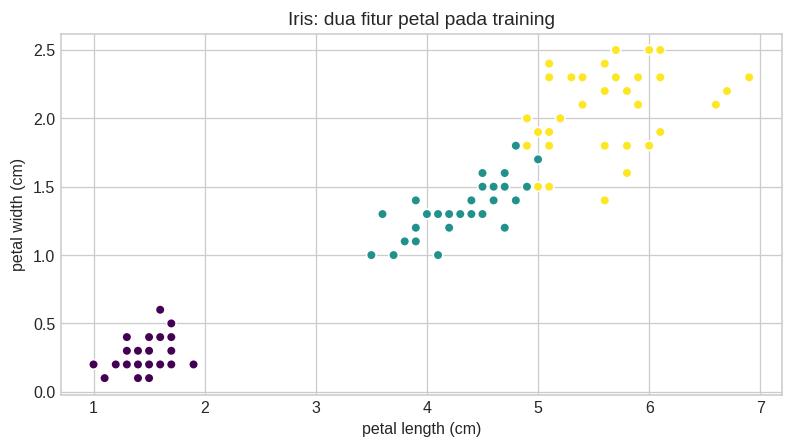

In [4]:
iris = load_iris()
Itrain, Itest, a, z = train_test_split(iris.data, iris.target, test_size=.3, stratify=iris.target, random_state=SEED)
multi = {
 'OvR': make_pipeline(StandardScaler(), OneVsRestClassifier(LogisticRegression(solver='liblinear', max_iter=5000, random_state=SEED))),
 'Multinomial': make_pipeline(StandardScaler(), LogisticRegression(solver='lbfgs', max_iter=5000, random_state=SEED))
}
multi_rows = []
for name, model in multi.items():
    model.fit(Itrain, a)
    p = model.predict_proba(Itest)
    assert np.allclose(p.sum(axis=1), 1)
    multi_rows.append({'model':name, **metrics(z,model.predict(Itest))})
display(pd.DataFrame(multi_rows).set_index('model'))
report(z, multi['Multinomial'].predict(Itest), list(iris.target_names))
fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(Itrain[:,2], Itrain[:,3], c=a, cmap='viridis', edgecolors='white')
ax.set(xlabel=iris.feature_names[2], ylabel=iris.feature_names[3], title='Iris: dua fitur petal pada training')
plt.tight_layout(); plt.show()

## 4. Regularisasi L1/L2 dan jalur koefisien
L1 menggunakan $R(w)=\sum_j |w_j|$ dan dapat menghasilkan koefisien tepat nol. L2 menggunakan jumlah kuadrat koefisien, sehingga koefisien menyusut tetapi biasanya tidak nol. Pada scikit-learn, **C adalah kebalikan kekuatan regularisasi**: C kecil berarti penalti lebih kuat. Nilai C yang besar tidak otomatis lebih baik.

Fitur wajib dibandingkan pada skala yang sepadan agar penalti tidak ditentukan satuan pengukuran. Jalur di bawah hanya menggunakan training; test belum dipakai untuk memilih C. Banyak koefisien yang saling berkorelasi dapat saling menggantikan pada L1; nol bukan bukti sebuah fitur tidak relevan secara universal. Dalam versi 1.8, `l1_ratio=1` menunjukkan L1 dan `l1_ratio=0` L2.

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_

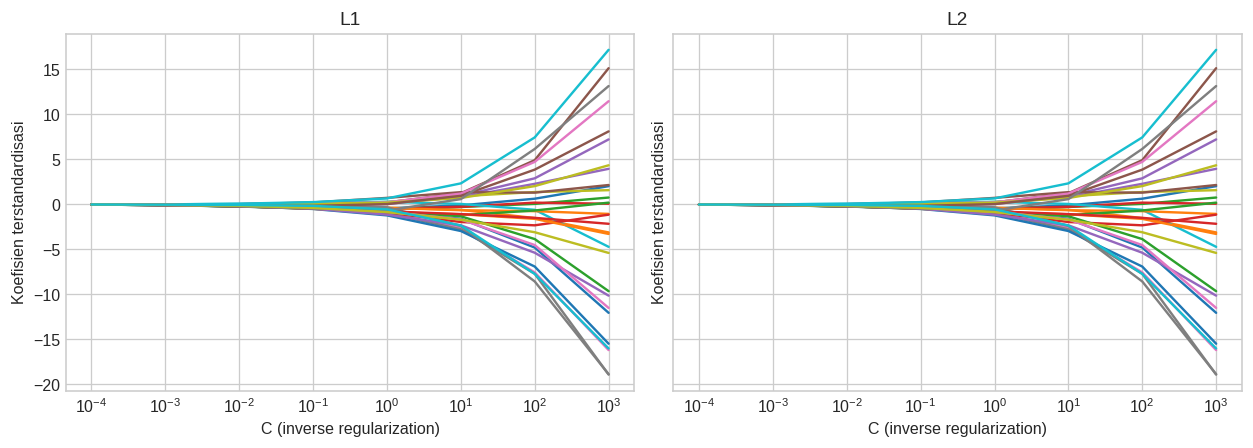

,penalty,C,nonzero_coefficients,accuracy,balanced_accuracy,macro_f1
0,L1,0.1,30,0.9825,0.9797,0.9812
1,L2,0.1,30,0.9825,0.9797,0.9812


In [5]:
Rtrain, Rtest, rtrain, rtest = train_test_split(X,y,test_size=.3,stratify=y,random_state=SEED)
Cs = np.logspace(-4,3,8)
paths, fixed = {}, {}
for name, ratio in [('L1',1),('L2',0)]:
    paths[name] = []
    for C in Cs:
        m = make_pipeline(StandardScaler(), LogisticRegression(solver='liblinear', l1_ratio=ratio,
                      C=float(C), max_iter=10000, random_state=SEED)).fit(Rtrain,rtrain)
        paths[name].append(m[-1].coef_[0])
    fixed[name] = make_pipeline(StandardScaler(), LogisticRegression(solver='liblinear', l1_ratio=ratio,
                      C=.1, max_iter=10000, random_state=SEED)).fit(Rtrain,rtrain)
fig, axes = plt.subplots(1,2,figsize=(11,4),sharey=True)
for ax,(name,coefs) in zip(axes,paths.items()):
    ax.semilogx(Cs,np.array(coefs)); ax.set(title=name, xlabel='C (inverse regularization)',ylabel='Koefisien terstandardisasi')
plt.tight_layout(); plt.show()
display(pd.DataFrame([{'penalty':name,'C':.1, 'nonzero_coefficients':int(np.count_nonzero(m[-1].coef_)),
    **metrics(rtest,m.predict(Rtest))} for name,m in fixed.items()]))

## 5. Multilabel dan hubungan antarlabel
Pada multilabel, satu sampel dapat memiliki beberapa label sekaligus. Matriks target berukuran $n\times L$ berisi nol/satu; baris dengan semua nol juga mungkin pada generator sumber. Strategi independent binary relevance melatih satu logistic classifier per label. Pendekatan ini efisien, tetapi tidak memodelkan ketergantungan label secara eksplisit.

**Subset accuracy** menuntut semua label pada satu baris tepat; **Hamming loss** menghitung proporsi keputusan label yang salah. Micro F1 menggabungkan semua keputusan label, sedangkan macro F1 memberi bobot sama untuk setiap label. Karena indikator multidimensi tidak sama dengan target multiclass, `stratify=Y` biasa bukan stratifikasi multilabel yang andal.

Untuk eksplorasi training, $M=Y^TY$ menghitung kemunculan bersama. $M_{ij}/M_{ii}$ mengestimasi $P(label_j=1\mid label_i=1)$; arah kondisional harus jelas. Koeksistensi bukan hubungan sebab akibat.

{'subset_accuracy': 0.33666666666666667, 'hamming_loss': 0.20866666666666667, 'micro_f1': 0.7004784688995215, 'macro_f1': 0.578510973122809}


,precision,recall,f1-score,support
label_0,0.8072,0.8072,0.8072,166.0
label_1,0.8000,0.8398,0.8194,181.0
label_2,0.6739,0.3333,0.4460,93.0
label_3,0.7500,0.1765,0.2857,34.0
label_4,0.5890,0.4886,0.5342,88.0
micro avg,0.7578,0.6512,0.7005,562.0
macro avg,0.7240,0.5291,0.5785,562.0
weighted avg,0.7452,0.6512,0.6771,562.0
samples avg,0.7183,0.6074,0.6188,562.0


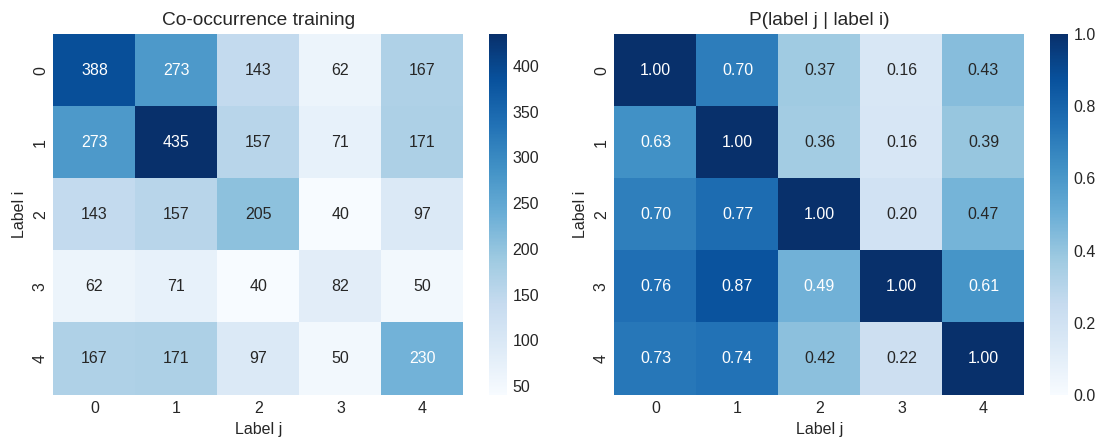

In [6]:
Xm, Ym = make_multilabel_classification(n_samples=1000,n_features=20,n_classes=5,n_labels=2,random_state=SEED)
Mt, Mv, Yt, Yv = train_test_split(Xm,Ym,test_size=.3,random_state=SEED)
ml = make_pipeline(StandardScaler(), OneVsRestClassifier(LogisticRegression(solver='liblinear',max_iter=5000,random_state=SEED)))
ml.fit(Mt,Yt); mp = ml.predict(Mv)
print({'subset_accuracy':accuracy_score(Yv,mp),'hamming_loss':hamming_loss(Yv,mp),
       'micro_f1':f1_score(Yv,mp,average='micro'),'macro_f1':f1_score(Yv,mp,average='macro')})
report(Yv,mp,[f'label_{i}' for i in range(5)])
co = Yt.T @ Yt
conditional = np.divide(co,np.diag(co)[:,None],out=np.zeros_like(co,dtype=float),where=np.diag(co)[:,None]!=0)
fig,axes=plt.subplots(1,2,figsize=(10,4))
sns.heatmap(co,annot=True,fmt='d',cmap='Blues',ax=axes[0]); axes[0].set(title='Co-occurrence training',xlabel='Label j',ylabel='Label i')
sns.heatmap(conditional,annot=True,fmt='.2f',vmin=0,vmax=1,cmap='Blues',ax=axes[1]); axes[1].set(title='P(label j | label i)',xlabel='Label j',ylabel='Label i')
plt.tight_layout(); plt.show()

## 6. Evaluasi: orientasi kelas positif, ROC dan PR
Dengan **malignant sebagai positif**, false negative berarti malignant diprediksi benign. Precision $=TP/(TP+FP)$, recall $=TP/(TP+FN)$, dan F1 adalah harmonic mean keduanya. Confusion matrix menampilkan jumlah pengamatan; baris adalah label aktual dan kolom prediksi.

ROC memplot true-positive rate terhadap false-positive rate pada berbagai threshold. ROC-AUC mengukur kualitas ranking, bukan accuracy atau kalibrasi probabilitas. Precision–recall lebih menonjolkan performa kelas positif ketika prevalensi rendah; baseline precision acak setara prevalensi positif. Average precision meringkas kurva PR dengan pembobotan perubahan recall, bukan identik dengan integrasi trapezoid.

Kolom probabilitas ditentukan melalui `classes_`, tidak diasumsikan selalu kolom kedua. Untuk evaluasi malignant, label diubah menjadi indikator `y == 0` tanpa mengubah label asli untuk training.

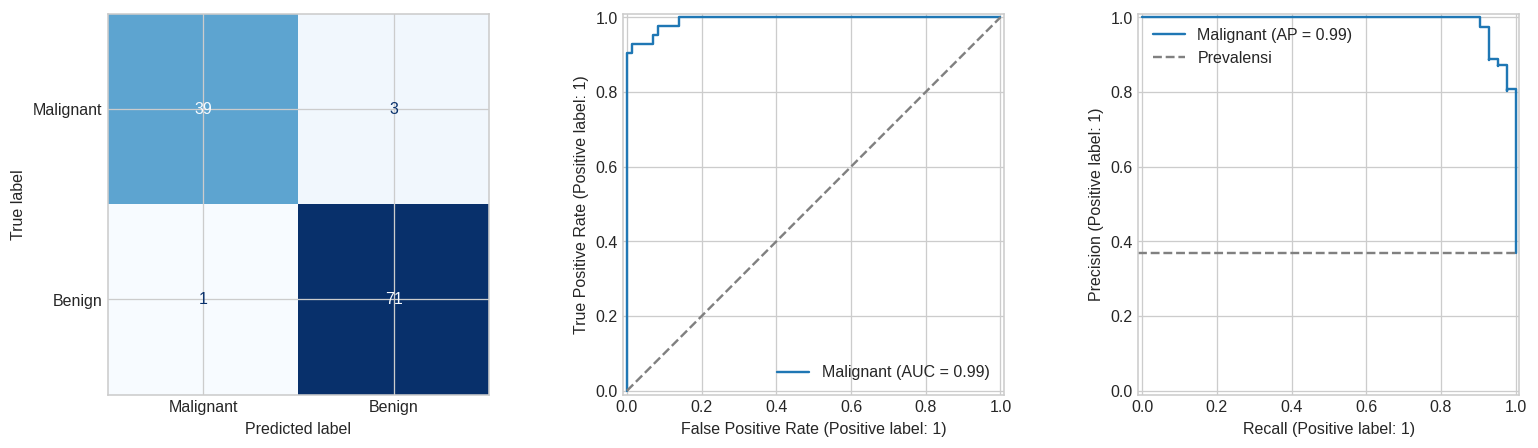

{'malignant_precision': 0.975, 'malignant_recall': 0.9285714285714286, 'ROC_AUC': np.float64(0.9927248677248678), 'average_precision': np.float64(0.9891409910026931)}


**Interpretasi:** ROC-AUC = 0.993 dan average precision = 0.989. Nilai ini berlaku untuk split benchmark ini. Probabilitas belum diuji kalibrasinya, dan model belum divalidasi pada pasien dari institusi lain.

In [7]:
positive_index = int(np.flatnonzero(binary.classes_ == 0)[0])
p_malignant = binary.predict_proba(Xte)[:,positive_index]
y_pos = (yte==0).astype(int)
auc = roc_auc_score(y_pos,p_malignant); ap = average_precision_score(y_pos,p_malignant)
fig,axes=plt.subplots(1,3,figsize=(14,4))
ConfusionMatrixDisplay.from_predictions(yte,pred,labels=[0,1],display_labels=['Malignant','Benign'],cmap='Blues',colorbar=False,ax=axes[0])
RocCurveDisplay.from_predictions(y_pos,p_malignant,ax=axes[1],name='Malignant'); axes[1].plot([0,1],[0,1],'--',color='gray')
PrecisionRecallDisplay.from_predictions(y_pos,p_malignant,ax=axes[2],name='Malignant'); axes[2].axhline(y_pos.mean(),ls='--',color='gray',label='Prevalensi')
axes[2].legend(); plt.tight_layout(); plt.show()
print({'malignant_precision':precision_score(yte,pred,pos_label=0),
       'malignant_recall':recall_score(yte,pred,pos_label=0),'ROC_AUC':auc,'average_precision':ap})
display(Markdown(f'**Interpretasi:** ROC-AUC = {auc:.3f} dan average precision = {ap:.3f}. '
 'Nilai ini berlaku untuk split benchmark ini. Probabilitas belum diuji kalibrasinya, dan model belum divalidasi pada pasien dari institusi lain.'))

## 7. Latihan terapan 1–3
**Latihan 1 — L1/L2:** implementasi inti ada di Bagian 4. Tambahkan pemilihan C melalui CV training saja. Pilih dengan balanced accuracy agar kedua kelas mendapat bobot sama.

**Latihan 2 — multinomial Iris:** model di Bagian 3 menyelesaikan klasifikasi tiga kelas. Di bawah, periksa CV training dan probabilitas untuk lima sampel test. Semua baris probabilitas harus berjumlah satu.

**Latihan 3 — batas keputusan biner:** generator sumber berisi 1.000 sampel dan dua fitur informatif. Batas logistic regression linear walaupun sigmoidnya nonlinear. Kurva probabilitas tidak otomatis membentuk batas nonlinear pada fitur asli.

In [8]:
cv = StratifiedKFold(5,shuffle=True,random_state=SEED)
search = GridSearchCV(make_pipeline(StandardScaler(),LogisticRegression(solver='liblinear',max_iter=10000,random_state=SEED)),
    {'logisticregression__C':[.01,.1,1,10], 'logisticregression__l1_ratio':[0,1]},
    cv=cv,scoring='balanced_accuracy',n_jobs=1,error_score='raise').fit(Rtrain,rtrain)
print('Latihan 1 best training-CV:',search.best_params_,round(search.best_score_,4))
print('Test:',metrics(rtest,search.predict(Rtest)))
iris_cv=cross_validate(clone(multi['Multinomial']),Itrain,a,cv=cv,scoring='accuracy')
print('Latihan 2 mean training-CV accuracy:',iris_cv['test_score'].mean())
display(pd.DataFrame(multi['Multinomial'].predict_proba(Itest[:5]),columns=iris.target_names))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_

Latihan 1 best training-CV: {'logisticregression__C': 1, 'logisticregression__l1_ratio': 0} 0.9798
Test: {'accuracy': 0.9707602339181286, 'balanced_accuracy': np.float64(0.9672167056074766), 'macro_f1': 0.9686870536531771}
Latihan 2 mean training-CV accuracy: 0.9523809523809522


,setosa,versicolor,virginica
0,0.9818,0.0182,2.1136e-07
1,0.0020,0.2429,7.5512e-01
2,0.9899,0.0101,7.4615e-08
3,0.0505,0.9363,1.3271e-02
4,0.1280,0.8630,8.9369e-03


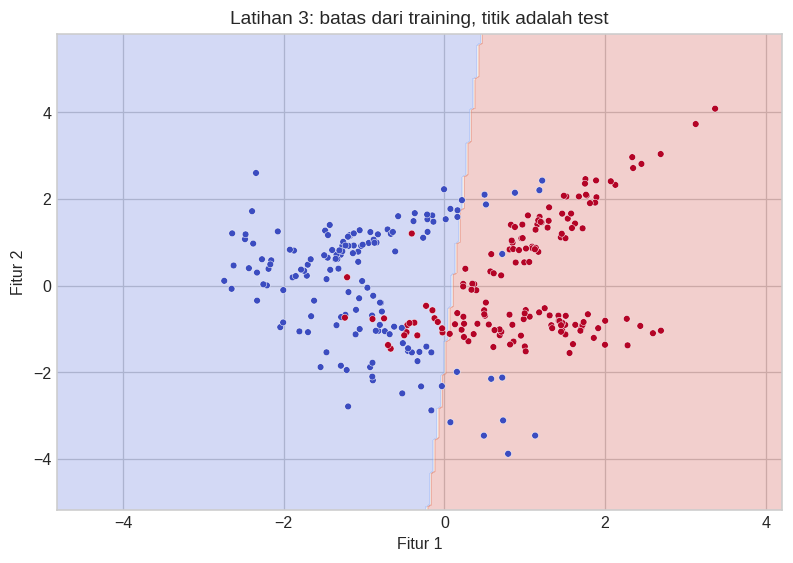

Synthetic test: {'accuracy': 0.8833333333333333, 'balanced_accuracy': np.float64(0.8834392639672874), 'macro_f1': 0.8833216654998833}


In [9]:
from sklearn.inspection import DecisionBoundaryDisplay
Xs, ys = make_classification(n_samples=1000,n_features=2,n_informative=2,n_redundant=0,random_state=SEED)
St,Sv,st,sv=train_test_split(Xs,ys,test_size=.3,stratify=ys,random_state=SEED)
boundary=make_pipeline(StandardScaler(),LogisticRegression(max_iter=5000,random_state=SEED)).fit(St,st)
fig,ax=plt.subplots(figsize=(7,5))
DecisionBoundaryDisplay.from_estimator(boundary,St,response_method='predict',grid_resolution=200,alpha=.25,ax=ax,cmap='coolwarm')
ax.scatter(Sv[:,0],Sv[:,1],c=sv,cmap='coolwarm',s=18,edgecolors='white',linewidths=.3)
ax.set(title='Latihan 3: batas dari training, titik adalah test',xlabel='Fitur 1',ylabel='Fitur 2')
plt.tight_layout(); plt.show()
print('Synthetic test:',metrics(sv,boundary.predict(Sv)))

## Ringkasan chapter
Logistic regression menghubungkan skor linear dengan probabilitas kelas. Regularisasi mengendalikan kompleksitas; nilainya dipilih memakai data training dan CV. OvR, multinomial, dan multilabel menyelesaikan struktur target yang berbeda. Evaluasi perlu baseline, hasil tiap kelas, dan definisi positif yang eksplisit. Grafik dan metrik di atas adalah output eksekusi, bukan jaminan performa pada populasi baru.

## Refleksi untuk dikerjakan sendiri
1. Jika biaya false negative malignant lebih besar, data mana yang boleh dipakai memilih threshold?
2. Mengapa koefisien L1 nol tidak selalu berarti fitur tersebut tidak berguna?
3. Mengapa subset accuracy multilabel biasanya lebih rendah daripada skor per-label?
4. Jelaskan perbedaan odds, probabilitas, accuracy, dan ROC-AUC dengan kata-kata sendiri.

## Referensi dan atribusi
- John Sukup. *scikit-learn Cookbook*, Third Edition. Packt Publishing, 2025. Kode pendamping Chapter 6 dan solusi latihan: [repository resmi](https://github.com/PacktPublishing/scikit-learn-Cookbook-Third-Edition/tree/c624b1279cf23a83273e806cede15cad0c9e5500).
- [Logistic regression dan solver, scikit-learn 1.8](https://scikit-learn.org/1.8/modules/linear_model.html#logistic-regression).
- [Multiclass dan multilabel](https://scikit-learn.org/1.8/modules/multiclass.html).
- [Metrik evaluasi](https://scikit-learn.org/1.8/modules/model_evaluation.html).
- Kode sumber pendamping berlisensi MIT; teks lisensi dipertahankan pada `THIRD_PARTY_NOTICES.md`. Penjelasan, koreksi metodologi, dan eksperimen tambahan pada notebook ini merupakan adaptasi belajar berbantuan AI. Baca, jalankan ulang, dan tulis refleksi pribadi sebelum menyerahkan tugas; jangan menyatakan bagian berbantuan AI sebagai pekerjaan mandiri tanpa mengikuti kebijakan kelas.